# Single-County Data Scaling: Cook County (FIPS 17031)

Learning curves for TabPFN vs XGBoost as training set size increases from 25 to 10,000 samples.
- 22 training sizes, **20 random seeds** per size
- Temporal train/test split (oldest 80% = train pool, most recent 20% = test)
- **107 features**: property characteristics (physical + missingness flags), assessor's market-value estimate (`MARKET_TOTAL_VALUE`), census/ACS demographics at block-group and tract level, lat/lon, temporal features
- Metrics: MAPE, MAE, RMSE, R²
- Shaded bands = **95% CI** across 20 seeds (mean ± 1.96 × SE)

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from pathlib import Path

RESULTS_PATH = Path("/nlp/scr/salilg/showcase_property_tax/results/single_county_scaling/v2_no_onehot/cook_county_20seeds/results.csv")

df = pd.read_csv(RESULTS_PATH)
df = df[df['status'] == 'success'].copy()

print(f"Rows: {len(df)}")
print(f"Models: {df['model'].unique()}")
print(f"Train sizes: {sorted(df['train_size'].unique())}")
print(f"Seeds per (model, train_size): {df.groupby(['model','train_size'])['seed'].count().unique()}")
df.head()

Rows: 880
Models: ['tabpfn' 'xgboost']
Train sizes: [np.int64(25), np.int64(50), np.int64(75), np.int64(100), np.int64(200), np.int64(300), np.int64(400), np.int64(500), np.int64(600), np.int64(700), np.int64(800), np.int64(900), np.int64(1000), np.int64(2000), np.int64(3000), np.int64(4000), np.int64(5000), np.int64(6000), np.int64(7000), np.int64(8000), np.int64(9000), np.int64(10000)]
Seeds per (model, train_size): [20]


,model,train_size,test_size,n_features,fit_time,pred_time,r2,mae,rmse,mape,mse,seed,county_fips,n_test,status
0,tabpfn,25,38849,107,5.266664,11.670617,0.723977,78977.357935,112333.901783,22.187226,1.261891e+10,0,17031,38849,success
1,xgboost,25,38849,107,4.977315,0.068754,0.446471,110007.562831,159077.243690,28.902606,2.530557e+10,0,17031,38849,success
2,tabpfn,50,38849,107,0.480046,11.998922,0.644114,83920.087606,131374.728399,24.868667,1.725932e+10,0,17031,38849,success
3,xgboost,50,38849,107,5.164612,0.033782,0.750981,80970.521617,109893.658008,26.324908,1.207662e+10,0,17031,38849,success
4,tabpfn,75,38849,107,0.472069,12.535089,-11.478311,105200.428849,809818.028099,27.676591,6.558052e+11,0,17031,38849,success


In [11]:
# Aggregate: mean, std, count across seeds; compute 95% CI half-width
Z95 = 1.96

agg = (
    df.groupby(['model', 'train_size'])[['mape', 'mae', 'rmse', 'r2']]
    .agg(['mean', 'std', 'count'])
    .reset_index()
)
agg.columns = ['model', 'train_size'] + [
    f"{m}_{s}" for m, s in agg.columns[2:]
]

# Add 95% CI half-width columns for each metric
for metric in ['mape', 'mae', 'rmse', 'r2']:
    agg[f'{metric}_ci95'] = Z95 * agg[f'{metric}_std'] / np.sqrt(agg[f'{metric}_count'])

tabpfn = agg[agg['model'] == 'tabpfn'].sort_values('train_size')
xgb    = agg[agg['model'] == 'xgboost'].sort_values('train_size')

agg[['model', 'train_size', 'mape_mean', 'mape_std', 'mape_ci95', 'mape_count']].head(6)

,model,train_size,mape_mean,mape_std,mape_ci95,mape_count
0,tabpfn,25,23.969055,1.652948,0.724436,20
1,tabpfn,50,23.629576,1.489103,0.652628,20
2,tabpfn,75,23.174933,1.667483,0.730806,20
3,tabpfn,100,23.006004,1.524017,0.667930,20
4,tabpfn,200,22.537888,0.845470,0.370543,20
5,tabpfn,300,22.442382,0.771901,0.338300,20


## Learning Curves — all metrics

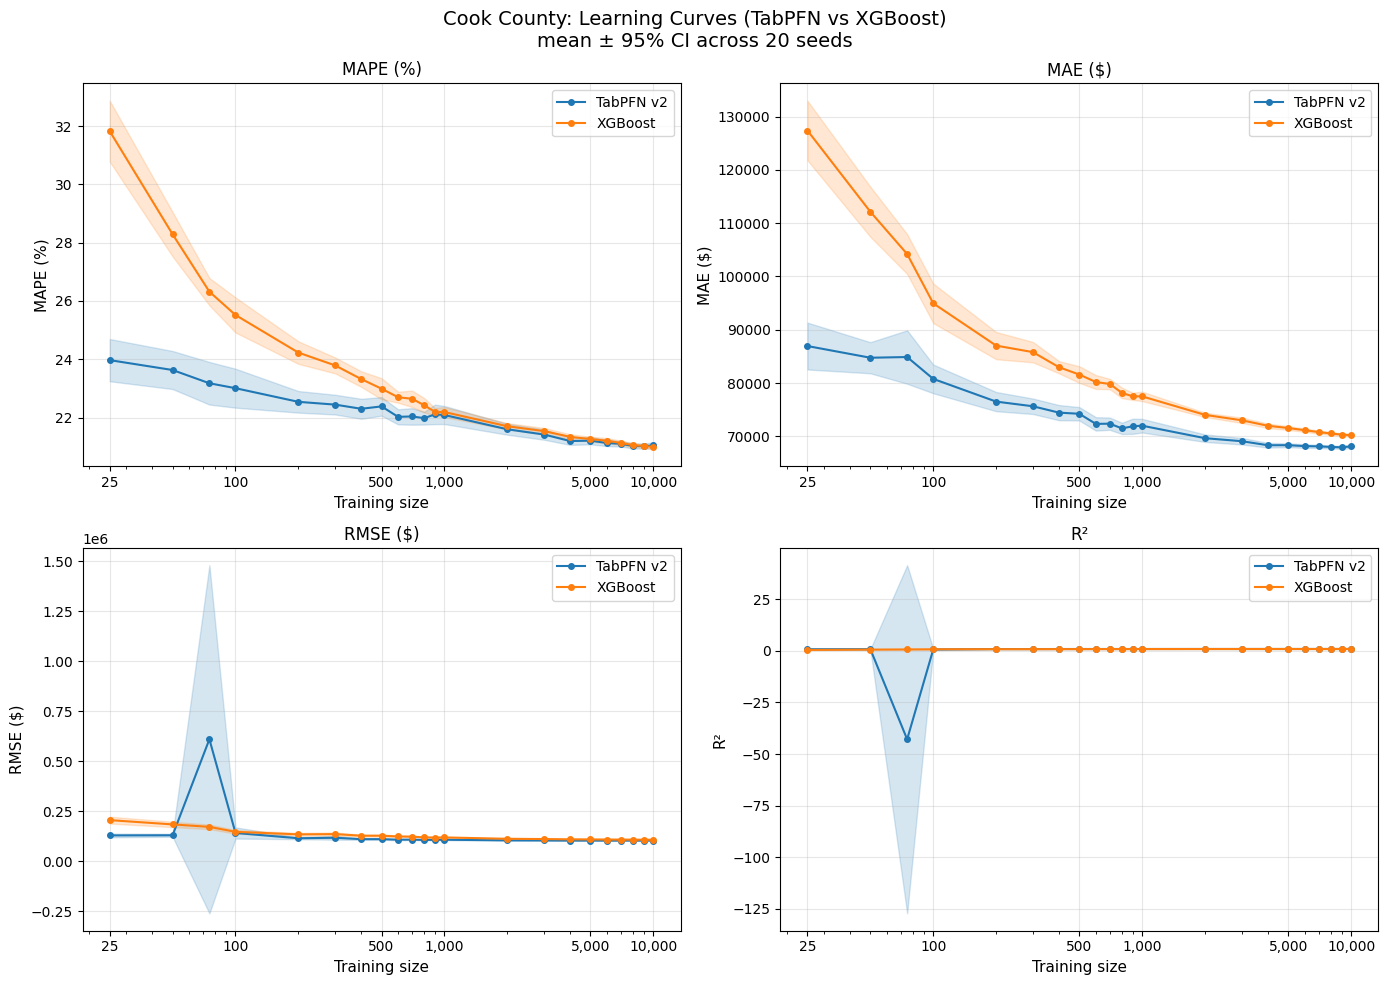

In [12]:
MODEL_COLORS = {
    'tabpfn':  '#1f77b4',   # blue
    'xgboost': '#ff7f0e',   # orange
}
MODEL_LABELS = {
    'tabpfn':  'TabPFN v2',
    'xgboost': 'XGBoost',
}

METRICS = [
    ('mape', 'MAPE (%)'),
    ('mae',  'MAE ($)'),
    ('rmse', 'RMSE ($)'),
    ('r2',   'R²'),
]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Cook County: Learning Curves (TabPFN vs XGBoost)\nmean ± 95% CI across 20 seeds', fontsize=14)

for ax, (metric, ylabel) in zip(axes.flatten(), METRICS):
    for model_df, model_name in [(tabpfn, 'tabpfn'), (xgb, 'xgboost')]:
        xs  = model_df['train_size'].values
        ys  = model_df[f'{metric}_mean'].values
        ci  = model_df[f'{metric}_ci95'].values
        color = MODEL_COLORS[model_name]
        label = MODEL_LABELS[model_name]

        ax.plot(xs, ys, marker='o', markersize=4, color=color, label=label)
        ax.fill_between(xs, ys - ci, ys + ci, alpha=0.18, color=color)

    ax.set_xlabel('Training size', fontsize=11)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.set_xscale('log')
    ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
    ax.xaxis.set_minor_formatter(ticker.NullFormatter())
    ax.set_xticks([25, 100, 500, 1000, 5000, 10000])
    ax.grid(True, which='major', alpha=0.3)
    ax.legend(fontsize=10)
    ax.set_title(ylabel)

plt.tight_layout()
plt.savefig('learning_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## MAPE: Main metric (larger plot)

In [ ]:
fig, ax = plt.subplots(figsize=(9, 5))

for model_df, model_name in [(tabpfn, 'tabpfn'), (xgb, 'xgboost')]:
    xs  = model_df['train_size'].values
    ys  = model_df['mape_mean'].values
    ci  = model_df['mape_ci95'].values
    color = MODEL_COLORS[model_name]
    label = MODEL_LABELS[model_name]

    ax.plot(xs, ys, marker='o', markersize=5, linewidth=2, color=color, label=label)
    ax.fill_between(xs, ys - ci, ys + ci, alpha=0.18, color=color)

ax.set_xlabel('Training size', fontsize=12)
ax.set_ylabel('MAPE (%)', fontsize=12)
ax.set_xscale('log')
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.xaxis.set_minor_formatter(ticker.NullFormatter())
ax.set_xticks([25, 50, 100, 200, 500, 1000, 2000, 5000, 10000])
ax.tick_params(axis='x', rotation=30)
ax.grid(True, which='major', alpha=0.3)
ax.legend(fontsize=11)
ax.set_title('Cook County MAPE vs Training Size\n(mean ± 95% CI across 20 seeds)', fontsize=12)

plt.tight_layout()
plt.savefig('mape_learning_curve.png', dpi=150, bbox_inches='tight')
plt.show()

## Crossover point: at what train size does XGBoost catch up / surpass TabPFN?

In [ ]:
merged = tabpfn[['train_size', 'mape_mean', 'mape_ci95']].merge(
    xgb[['train_size', 'mape_mean', 'mape_ci95']],
    on='train_size', suffixes=('_tabpfn', '_xgb')
)
merged['tabpfn_wins'] = merged['mape_mean_tabpfn'] < merged['mape_mean_xgb']
merged['mape_gap'] = (merged['mape_mean_xgb'] - merged['mape_mean_tabpfn']).round(3)
# Significant if gap > sum of CI half-widths (non-overlapping CIs)
merged['significant'] = merged['mape_gap'].abs() > (merged['mape_ci95_tabpfn'] + merged['mape_ci95_xgb'])

print("MAPE comparison (lower is better):")
print(merged[['train_size', 'mape_mean_tabpfn', 'mape_mean_xgb', 'mape_gap', 'tabpfn_wins', 'significant']].to_string(index=False))

## Per-seed scatter (variability)

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))

for model_name in ['tabpfn', 'xgboost']:
    sub = df[df['model'] == model_name]
    color = MODEL_COLORS[model_name]
    label = MODEL_LABELS[model_name]
    jitter = np.random.RandomState(0).uniform(-0.02, 0.02, len(sub))
    xs = sub['train_size'].values * (10 ** jitter)
    ax.scatter(xs, sub['mape'].values, alpha=0.15, s=6, color=color, label=label)

# Overlay means
for model_df, model_name in [(tabpfn, 'tabpfn'), (xgb, 'xgboost')]:
    ax.plot(
        model_df['train_size'], model_df['mape_mean'],
        color=MODEL_COLORS[model_name], linewidth=2
    )

ax.set_xscale('log')
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.xaxis.set_minor_formatter(ticker.NullFormatter())
ax.set_xticks([25, 100, 500, 1000, 5000, 10000])
ax.tick_params(axis='x', rotation=30)
ax.set_xlabel('Training size', fontsize=12)
ax.set_ylabel('MAPE (%)', fontsize=12)
ax.set_title('MAPE per seed (dots) with mean (line)', fontsize=12)
ax.grid(True, which='major', alpha=0.3)

handles, labels = ax.get_legend_handles_labels()
seen = {}
for h, l in zip(handles, labels):
    if l not in seen:
        seen[l] = h
ax.legend(seen.values(), seen.keys(), fontsize=11)

plt.tight_layout()
plt.savefig('mape_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

## Summary table

In [ ]:
summary = (
    df.groupby(['model', 'train_size'])
    .agg(
        mape_mean=('mape', 'mean'),
        mape_std=('mape', 'std'),
        r2_mean=('r2', 'mean'),
        mae_mean=('mae', 'mean'),
        n=('mape', 'count'),
    )
    .round(3)
    .reset_index()
)
summary